In [6]:
dates = [20260522,20260525]

In [7]:
import pandas as pd
import ast

rows = []

with open("ticker_data_log/mats_logs_20260528.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        try:
            parts = line.split(",", 5)

            timestamp = parts[0]
            name = parts[1]

            data = ast.literal_eval(parts[5])

            row = {
                "timestamp": timestamp,
                "name": name,
                "bid": float(data["bid"]),
                "ask": float(data["ask"]),
                "bidsize": float(data["bidsize"]),
                "asksize": float(data["asksize"]),
                "last": float(str(data["last"]).replace(",", ".")),
                "close": float(data["close"]),
            }

            rows.append(row)

        except Exception as e:
            print("Error parsing line:")

df = pd.DataFrame(rows)

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%Y%m%d-%H%M%S"
)
print()

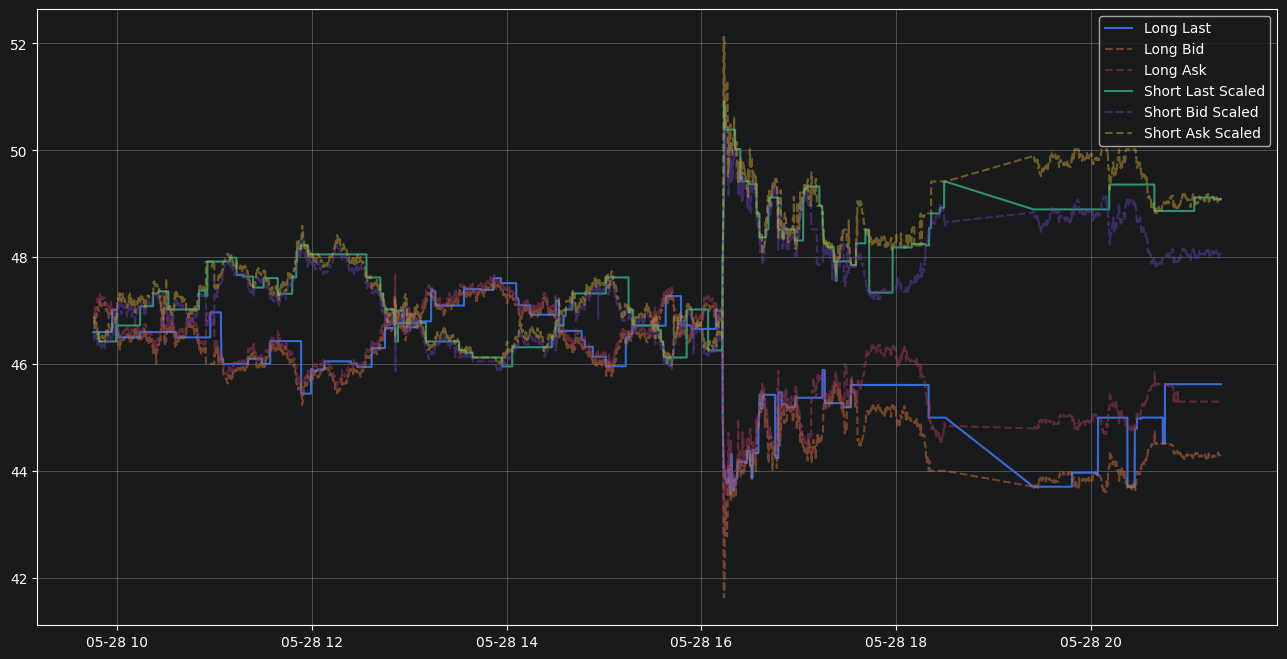

In [8]:
import matplotlib.pyplot as plt

# split tickers
df_long = df[df["name"] == "Oil 3X Daily"].copy()
df_short = df[df["name"] == " Oil 3x Short"].copy()

# sorteren
df_long = df_long.sort_values("timestamp")
df_short = df_short.sort_values("timestamp")

# scale factor
scale_factor = (
    df_long["last"].iloc[0]
    /
    df_short["last"].iloc[0]
)

# scaled kolommen
for col in ["last", "bid", "ask"]:
    df_short[f"{col}_scaled"] = df_short[col] * scale_factor

# plot
plt.figure(figsize=(16,8))

# LONG
plt.plot(
    df_long["timestamp"],
    df_long["last"],
    label="Long Last"
)

plt.plot(
    df_long["timestamp"],
    df_long["bid"],
    alpha=0.5,
    linestyle="--",
    label="Long Bid"
)

plt.plot(
    df_long["timestamp"],
    df_long["ask"],
    alpha=0.5,
    linestyle="--",
    label="Long Ask"
)

# SHORT scaled
plt.plot(
    df_short["timestamp"],
    df_short["last_scaled"],
    label="Short Last Scaled"
)

plt.plot(
    df_short["timestamp"],
    df_short["bid_scaled"],
    alpha=0.5,
    linestyle="--",
    label="Short Bid Scaled"
)

plt.plot(
    df_short["timestamp"],
    df_short["ask_scaled"],
    alpha=0.5,
    linestyle="--",
    label="Short Ask Scaled"
)

plt.legend()
plt.grid(True)
plt.show()

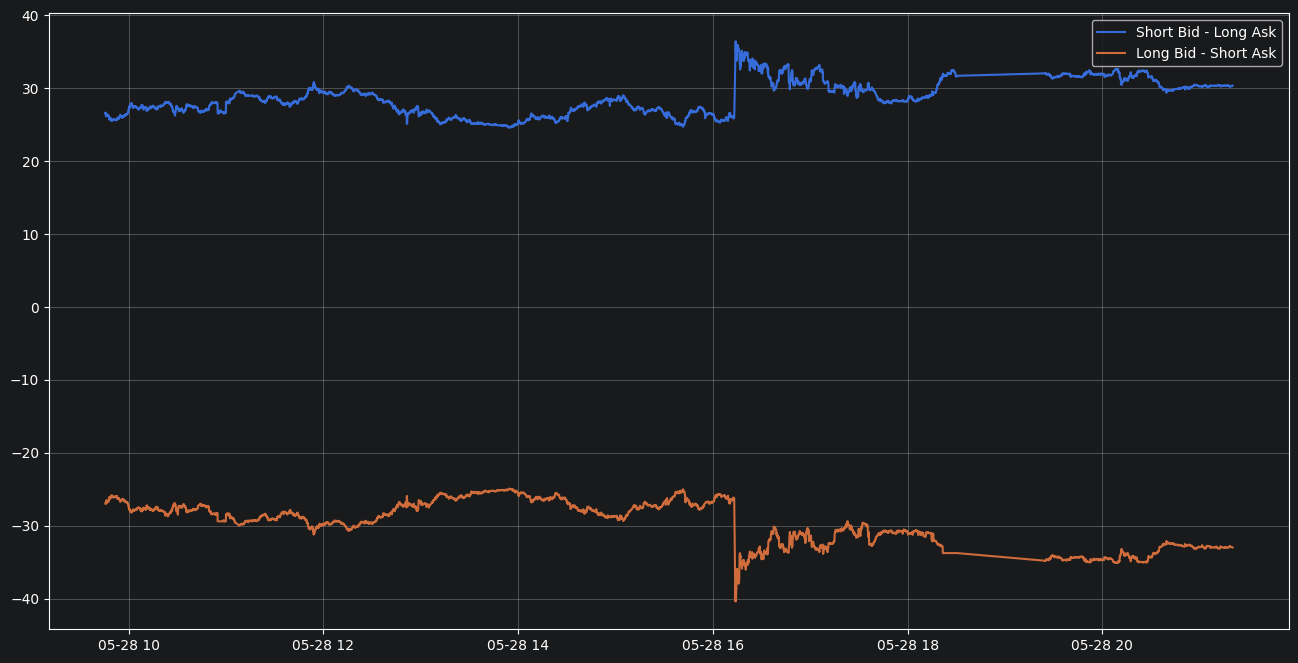

In [9]:
import matplotlib.pyplot as plt

# split tickers
df_long = df[df["name"] == "Oil 3X Daily"].copy()
df_short = df[df["name"] == " Oil 3x Short"].copy()

# sorteren
df_long = df_long.sort_values("timestamp")
df_short = df_short.sort_values("timestamp")

# timestamp als index
df_long = df_long.set_index("timestamp")
df_short = df_short.set_index("timestamp")

# scale factor gebaseerd op eerste last price
scale_factor = (47.13
    # df_long["last"].iloc[0]
    # /
    # df_short["last"].iloc[0]
)

# short schalen
for col in ["last", "bid", "ask"]:
    df_short[f"{col}_scaled"] = (
        df_short[col] * scale_factor
    )

# executable scenarios
df_combined = pd.DataFrame(index=df_long.index)

df_combined["long_bid"] = df_long["bid"]
df_combined["long_ask"] = df_long["ask"]
df_combined["long_last"] = df_long["last"]

df_combined["short_last"] = df_short["last"]
df_combined["short_bid"] = df_short["bid"]
df_combined["short_ask"] = df_short["ask"]

df_combined["short_bid_scaled"] = df_short["bid_scaled"]
df_combined["short_ask_scaled"] = df_short["ask_scaled"]
df_combined["short_last_scaled"] = df_short["last_scaled"]

# scenario 1:
# verkoop short op bid
# koop long op ask
df_combined["short_bid_minus_long_ask"] = (
    df_combined["short_bid_scaled"]
    -
    df_combined["long_ask"]
)

# scenario 2:
# verkoop long op bid
# koop short op ask
df_combined["long_bid_minus_short_ask"] = (
    df_combined["long_bid"]
    -
    df_combined["short_ask_scaled"]
)

# beste executable edge
df_combined["max_edge"] = df_combined[
    [
        "short_bid_minus_long_ask",
        "long_bid_minus_short_ask"
    ]
].max(axis=1)

# plot
plt.figure(figsize=(16,8))

plt.plot(
    df_combined.index,
    df_combined["short_bid_minus_long_ask"],
    label="Short Bid - Long Ask"
)

plt.plot(
    df_combined.index,
    df_combined["long_bid_minus_short_ask"],
    label="Long Bid - Short Ask"
)

# plt.plot(
#     df_combined.index,
#     df_combined["max_edge"],
#     linewidth=3,
#     label="Max Edge"
# )

#plt.axhline(0, linestyle="--")

plt.legend()
plt.grid(True)
plt.show()

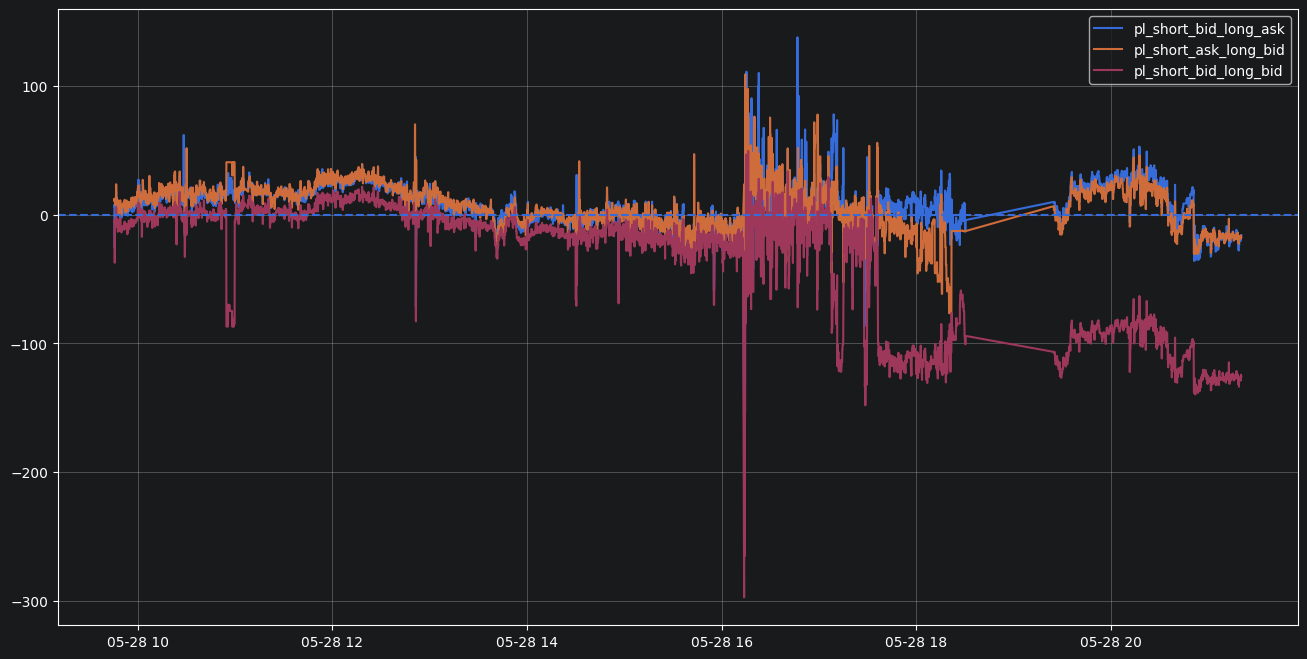

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
#long_open = 59.45 #25
#short_open = 1.2615 #25
#long_open = 47 #22
#short_open = 1.5422 #25

open_dates = ["22/05""25/05","26/05""27/05","28/05"]
short_opens_list =  [1.5603]
long_opens_list = [46.81]




short_open = 1.5272
long_open = 48.662

short_open = 1.5603
long_open = 46.81

df_combined["pl_short_bid_long_ask"] = (5000/short_open * (df_combined["short_bid"] - short_open) + 5000/long_open*(df_combined["long_ask"] - long_open))
df_combined["pl_short_ask_long_bid"] = (5000/short_open * (df_combined["short_ask"] - short_open) + 5000/long_open*(df_combined["long_bid"] - long_open))
df_combined["pl_short_bid_long_bid"] = (5000/short_open * (df_combined["short_bid"] - short_open) + 5000/long_open*(df_combined["long_bid"] - long_open))

plt.plot(
    df_combined.index,
    df_combined["pl_short_bid_long_ask"],
    label="pl_short_bid_long_ask"
)

plt.plot(
    df_combined.index,
    df_combined["pl_short_ask_long_bid"],
    label="pl_short_ask_long_bid"
)

plt.plot(
    df_combined.index,
    df_combined["pl_short_bid_long_bid"],
    label="pl_short_bid_long_bid"
)
plt.axhline(0, linestyle="--")

plt.legend()
plt.grid(True)

plt.show()

In [152]:
#long open dag 2 7:45
#
# long_opens = [65.500,66.270,68.688,59.860,59.450]
# long_close = [63.750,67.899,57.807,59.518,56]
#
# short_opens = [1.178,1.180,1.174,1.30,1.262]
# short_close = [1.201,1.149,1.350,1.30,1.340]
#
#
# scale_factors =[]
# for i in range(len(long_opens)):
#     scale_factors.append(long_opens[i]/short_opens[i])
#
# pair_close = []
# for i in range(len(short_close)):
#     value =5000/long_opens[i] * (long_close[i] - long_opens[i]) + 5000/short_opens[i] * (short_close[i] - short_opens[i])
#     pair_close.append(value)
#
# print(pair_close)
#
#
#

